# 10. PyGIMLi forward models for karst reference survey

This notebook builds the YAML-driven three-layer reference model, creates the oversampled source--receiver geometry, runs the expensive PyGIMLi forward travel-time simulations once, and caches the resulting travel-time tables for downstream analysis.

Run this notebook when the earth model, cave geometry, mesh settings, or oversampled survey geometry changes. For subsetting, detectability tests, and inversions, use the companion `20_pygimli_subsetting_and_inversion.ipynb` notebook so that you do not rerun the large forward model unnecessarily.

## Scientific questions

This notebook is meant to answer:

1. **Can the cave be detected in first-arrival travel times?**
2. **Which ray paths are most sensitive to the cave?**
3. **How much do we lose if we remove shots?**
4. **How much do we lose if we remove geophones?**
5. **How much aperture do we need?**
6. **Does a dense geophone line outperform a sparse nodal line?**
7. **Should we estimate the background 2-layer model first, away from the cave, before looking for cave anomalies?**

The answer to the last question is probably **yes**. A good workflow is:

- First estimate or constrain the 1-D/2-layer background using shots and receivers away from the suspected cave zone.
- Then look for structured residuals around the suspected cave.
- Finally invert selected datasets for 2-D velocity anomalies and compare how well the cave is imaged.

In [1]:
from pathlib import Path
import copy
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.meshtools as mt
import pygimli.physics.traveltime as tt


pg.utils.units.quants["vel"]["cMap"] = "inferno_r"
import json

## 1. Load YAML configuration

The notebook is driven by a single YAML configuration file. The YAML defines:

- modelling domain;
- survey geometry;
- earth-model layers;
- cave geometry and water properties;
- PyGIMLi mesh and decimation settings.

The earth model may define either constant values:

```yaml
vp_m_s: 2500
```

or top/bottom values:

```yaml
vp_top_m_s: 2500
vp_bottom_m_s: 4200
```

If `earth_model.gradient.enabled: false`, the code uses the average of top and bottom values for each layer. If gradients are enabled, values are linearly interpolated with depth within each layer.


In [2]:
# Change this if you want to point the notebook at another YAML file.
CONFIG_FILE = Path("karst_reference_oversampled_survey.yml")

# Helpful fallback when running from a different working directory, e.g. after upload.
if not CONFIG_FILE.exists():
    fallback = Path("/mnt/data") / CONFIG_FILE.name
    if fallback.exists():
        CONFIG_FILE = fallback

if not CONFIG_FILE.exists():
    raise FileNotFoundError(
        "Could not find karst_reference_oversampled_survey.yml. "
        "Place it in the notebook directory, or set CONFIG_FILE explicitly."
    )

with CONFIG_FILE.open("r") as f:
    cfg = yaml.safe_load(f)

OUTPUT_DIR = Path("/Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/pygimli3")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

reference_dir = OUTPUT_DIR / "reference_model"
figure_dir = OUTPUT_DIR / "figures"
table_dir = OUTPUT_DIR / "tables"
for d in [reference_dir, figure_dir, table_dir]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Loaded: {CONFIG_FILE}")
print(f"Output directory: {OUTPUT_DIR}")
print("Top-level YAML keys:", list(cfg.keys()))


Loaded: karst_reference_oversampled_survey.yml
Output directory: /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/pygimli3
Top-level YAML keys: ['compute', 'output', 'domain', 'deepwave', 'survey', 'earth_model', 'cave', 'coordinate_convention', 'pygimli']


## 2. PyGIMLi Configuration: Reference Model and Survey Design Parameters

This section defines the configuration (pgcfg) used for forward modelling, noise simulation, inversion control, and survey design experiments.

The configuration is built in two stages:

1. Default parameters (pygimli_defaults) — define a high-quality reference model
2. YAML overrides (cfg["pygimli"]) — allow external customization

⸻

### Mesh Design

The mesh controls how accurately ray paths and velocity contrasts are represented.

* Background mesh resolution (mesh_area_m2 = 0.50)
    * Controls average triangle size outside the cave
    * Smaller values give higher accuracy but increase computation time
* Cave mesh refinement (cave_mesh_area_m2 = 0.025)
    * Very fine resolution inside the cave
    * Required to capture strong velocity contrast (e.g., rock vs water)
* Cave buffer zone
    * cave_buffer_m = 10.0
    * cave_buffer_mesh_area_m2 = 0.05
    * Creates a refinement halo around the cave
    * Important because ray bending occurs outside the void
* Mesh quality (mesh_quality = 34.0)
    * Controls triangle shape regularity
    * Higher values improve numerical stability

To ensure a consistent high-quality reference model, the code enforces minimum refinement:

* Background mesh is not allowed to become coarser than 0.5 m²
* Cave mesh is not allowed to become coarser than 0.025 m²
* Buffer region is always at least 10 m wide

⸻

### Synthetic Noise Model

These parameters simulate realistic picking uncertainty in synthetic data:

* noise_level_relative = 0.001 (0.1%)
* noise_abs_s = 0.0005 (0.5 ms minimum)

This represents high-quality data and sets the lower bound for detectable signals.

⸻

### Inversion Error Model

These parameters control data weighting during inversion:

* error_relative = 0.03 (3%)
* error_abs_s = 0.001 (1 ms minimum)

Note the distinction:

* Noise affects synthetic data generation
* Error affects inversion weighting

⸻

### Survey Geometry Selection

These flags control which acquisition components are used:

* use_cabled_receivers = True
* use_smartsolo_receivers = False
* use_regular_shots = True

The reference model uses a dense 1 m receiver line. Sparse arrays (e.g., 4 m nodal spacing) are not modelled separately; instead, they are created later by subsetting the full dataset.

⸻

### Inversion Settings

Key inversion parameters include:

* sec_nodes = 2 — improves ray tracing accuracy
* para_max_cell_size_m2 = 5.0 — controls inversion mesh resolution
* lam = 20.0 — regularization strength
* max_iter = 8 — number of iterations

In this notebook:

* run = False

This means inversion is disabled during the reference run. The focus is on forward modelling and survey design. Selected inversions can be run later on reduced datasets.

⸻

### Decimation Experiments (Survey Optimization)

This is a key part of the workflow. The full synthetic dataset is computed once and then systematically reduced to simulate different survey designs.

The following parameters define the test space:

* Receiver spacing: 1, 2, 3, 4, 5, 10 m
* Shot spacing: 1, 2, 4, 5, 10 m
* Receiver aperture (halfwidth): 25, 35, 50, 75 m
* Shot aperture (halfwidth): 40, 60, 80, 100 m

This allows evaluation of:

* Dense vs sparse arrays
* Short vs long survey lines
* Trade-offs between spacing and aperture

⸻

### Configuration Merging

The final configuration is constructed by merging defaults with YAML input:

* Defaults define a safe, high-quality baseline
* YAML allows overriding parameters for experiments

Nested dictionaries (e.g., inversion and decimation settings) are merged explicitly.

⸻

### Final Enforcement

The code ensures:

* The mesh remains sufficiently fine
* Inversion is disabled for the reference run

This guarantees that:

Any differences observed in the results are due to survey design choices, not numerical artefacts.

⸻

### Summary

This configuration defines a high-resolution reference model designed to:

* Accurately capture cave-induced travel-time perturbations
* Provide a consistent baseline for comparison
* Enable systematic evaluation of survey geometry

The philosophy is:

Compute one high-quality synthetic dataset, then explore survey design by subsetting it rather than recomputing forward models.


In [3]:
pygimli_defaults = {
    # Plotting controls.
    "plotting": {
        "cmap": "inferno_r",
        "vp_cmin_m_s": None,
        "vp_cmax_m_s": None,
    },
}

pgcfg = copy.deepcopy(pygimli_defaults)
pgcfg.update(cfg.get("pygimli", {}))
pgcfg["inversion"].update(cfg.get("pygimli", {}).get("inversion", {}))
pgcfg["decimation_experiments"].update(cfg.get("pygimli", {}).get("decimation_experiments", {}))
pgcfg["plotting"].update(cfg.get("pygimli", {}).get("plotting", {}))

pgcfg


{'plotting': {'cmap': 'inferno_r', 'vp_cmin_m_s': None, 'vp_cmax_m_s': None},
 'mesh_quality': 34.0,
 'mesh_area_m2': 0.5,
 'cave_mesh_area_m2': 0.5,
 'cave_buffer_m': 10.0,
 'cave_buffer_mesh_area_m2': 0.5,
 'noise_level_relative': 0.001,
 'noise_abs_s': 0.0001,
 'error_relative': 0.001,
 'error_abs_s': 0.0001,
 'seed': 20260424,
 'use_cabled_receivers': True,
 'use_smartsolo_receivers': False,
 'use_extra_shots': False,
 'use_node_shots': False,
 'use_regular_shots': True,
 'inversion': {'run': True,
  'sec_nodes': 2,
  'para_max_cell_size_m2': 5.0,
  'max_iter': 8,
  'lam': 50.0},
 'decimation_experiments': {'receiver_spacings_m': [0.5, 1, 2, 3, 4, 5, 10],
  'shot_spacings_m': [1, 2, 4, 5, 10],
  'receiver_halfwidths_m': [25, 35, 50, 75, 100, 150],
  'shot_halfwidths_m': [40, 60, 80, 100, 150],
  'description': 'Generate the full 1 m shot/receiver travel-time table first, then subset by shot spacing, receiver spacing, and aperture for survey-design tests.'}}

## 3. Coordinate system and layer/property functions

This section defines the core logic for assigning material properties from the YAML file.

Important behaviour:

- The YAML uses `z_min_m` and `z_max_m` as **depths positive downward**.
- PyGIMLi uses `y` positive upward, so depth is `-y`.
- Layers are evaluated by cell-centre depth.
- If gradients are disabled, and a layer has top/bottom values, the value used is the arithmetic mean.
- If gradients are enabled, top/bottom values are linearly interpolated within the layer.

This makes two-layer and three-layer models use the same code path.


In [4]:
def depth_to_y(depth_m):
    """Convert depth, positive downward, to PyGIMLi y-coordinate."""
    return -float(depth_m)


def y_to_depth(y_m):
    """Convert PyGIMLi y-coordinate to depth, positive downward."""
    return -float(y_m)


def _as_float_or_nan(value):
    """Return float(value), allowing missing values to become NaN."""
    if value is None:
        return np.nan
    try:
        return float(value)
    except Exception:
        return np.nan


def layer_at_depth(depth_m, cfg):
    """
    Return the earth-model layer corresponding to a depth.

    The first layer satisfying z_min <= depth < z_max is used. The bottom
    boundary of the deepest layer is included.
    """
    depth_m = float(depth_m)
    layers = cfg["earth_model"].get("layers", [])
    if not layers:
        raise ValueError("earth_model.layers is empty or missing")

    for i, layer in enumerate(layers):
        z0 = float(layer["z_min_m"])
        z1 = float(layer["z_max_m"])
        is_last = i == len(layers) - 1
        if (z0 <= depth_m < z1) or (is_last and z0 <= depth_m <= z1):
            return layer

    # Fallback to background if a cell is just outside the defined layers.
    bg = cfg["earth_model"].get("background", {})
    return {
        "name": "background",
        "z_min_m": cfg["domain"].get("z_min_m", 0.0),
        "z_max_m": cfg["domain"].get("z_max_m", 0.0),
        "vp_m_s": bg.get("vp_m_s", np.nan),
        "vs_m_s": bg.get("vs_m_s", np.nan),
        "density_kg_m3": bg.get("density_kg_m3", np.nan),
        "qkappa": bg.get("qkappa", np.nan),
        "qmu": bg.get("qmu", np.nan),
    }


def layer_property_value(cfg, layer, prop_name, depth_m):
    """
    Return a layer property at a given depth.

    Supported YAML styles:

    Constant value:
        vp_m_s: 2500

    Top/bottom values:
        vp_top_m_s: 2500
        vp_bottom_m_s: 4200

    If gradients are disabled, top/bottom values are averaged. If gradients are
    enabled, top/bottom values are linearly interpolated with depth.
    """
    grad_cfg = cfg["earth_model"].get("gradient", {})
    gradient_enabled = bool(grad_cfg.get("enabled", False))

    # 1. Constant property value wins if explicitly present.
    if prop_name in layer:
        return float(layer[prop_name])

    # 2. Otherwise use top/bottom pair if present.
    if prop_name.endswith("_m_s"):
        base = prop_name[:-4]  # vp_m_s -> vp ; vs_m_s -> vs
        top_key = f"{base}_top_m_s"
        bottom_key = f"{base}_bottom_m_s"
    elif prop_name == "density_kg_m3":
        top_key = "density_top_kg_m3"
        bottom_key = "density_bottom_kg_m3"
    else:
        top_key = f"{prop_name}_top"
        bottom_key = f"{prop_name}_bottom"

    if top_key in layer and bottom_key in layer:
        top = float(layer[top_key])
        bottom = float(layer[bottom_key])

        if not gradient_enabled:
            return 0.5 * (top + bottom)

        z0 = float(layer["z_min_m"])
        z1 = float(layer["z_max_m"])
        if z1 == z0:
            return 0.5 * (top + bottom)
        frac = np.clip((float(depth_m) - z0) / (z1 - z0), 0.0, 1.0)
        return top + frac * (bottom - top)

    # 3. Fallback to background value.
    bg = cfg["earth_model"].get("background", {})
    if prop_name in bg:
        return float(bg[prop_name])

    return np.nan


def material_properties_at_depth(cfg, depth_m):
    """
    Return Vp, Vs, density, and Q values at a given depth.

    This function is the single source of truth for assigning ordinary earth
    properties to mesh cells. Cave cells are handled separately.
    """
    layer = layer_at_depth(depth_m, cfg)

    return {
        "name": layer.get("name", "unknown"),
        "vp": layer_property_value(cfg, layer, "vp_m_s", depth_m),
        "vs": layer_property_value(cfg, layer, "vs_m_s", depth_m),
        "rho": layer_property_value(cfg, layer, "density_kg_m3", depth_m),
        "qkappa": _as_float_or_nan(layer.get("qkappa", cfg["earth_model"].get("background", {}).get("qkappa"))),
        "qmu": _as_float_or_nan(layer.get("qmu", cfg["earth_model"].get("background", {}).get("qmu"))),
    }


def cave_material(cfg):
    """Return material properties for a water-filled cave/void."""
    water = cfg["cave"].get("water", {})
    return {
        "vp": float(water.get("vp_m_s", 1500.0)),
        "vs": float(water.get("vs_m_s", 0.0)),
        "rho": float(water.get("density_kg_m3", 1000.0)),
        "qkappa": _as_float_or_nan(water.get("qkappa", np.nan)),
        "qmu": _as_float_or_nan(water.get("qmu", np.nan)),
    }


def layer_property_summary(cfg):
    """Summarize effective layer properties at each layer midpoint."""
    rows = []
    for i, layer in enumerate(cfg["earth_model"].get("layers", []), start=1):
        zmid = 0.5 * (float(layer["z_min_m"]) + float(layer["z_max_m"]))
        mat = material_properties_at_depth(cfg, zmid)
        rows.append({
            "marker": i,
            "name": layer.get("name", f"layer_{i}"),
            "z_min_m": float(layer["z_min_m"]),
            "z_max_m": float(layer["z_max_m"]),
            "z_mid_m": zmid,
            "vp_effective_m_s": mat["vp"],
            "vs_effective_m_s": mat["vs"],
            "density_effective_kg_m3": mat["rho"],
            "qkappa": mat["qkappa"],
            "qmu": mat["qmu"],
        })
    return pd.DataFrame(rows)


print("Gradient enabled:", bool(cfg["earth_model"].get("gradient", {}).get("enabled", False)))
display(layer_property_summary(cfg))


Gradient enabled: False


,marker,name,z_min_m,z_max_m,z_mid_m,vp_effective_m_s,vs_effective_m_s,density_effective_kg_m3,qkappa,qmu
0,1,unsaturated_limestone,0.0,10.0,5.0,1600.0,800.0,2050.0,60.0,25.0
1,2,saturated_limestone_upper,10.0,35.0,22.5,3600.0,1800.0,2280.0,100.0,40.0
2,3,saturated_limestone_lower_or_basement,35.0,50.0,42.5,4700.0,2600.0,2450.0,150.0,60.0


## 4. Survey Geometry: Receivers and Shot Locations

This section constructs the **reference survey geometry** from the YAML configuration.

### 🔹 Receivers (Cabled Geophone Line)

The reference model uses a dense, uniformly spaced geophone array:

- Defined in `cfg["survey"]["cabled"]`
- Parameters:
  - `start_m`: starting position along profile
  - `spacing_m`: receiver spacing
  - `n_channels`: number of receivers
  - `receiver_depth_m`: burial depth

Each receiver is assigned:

- Horizontal position (`x_m`)
- Depth (`z_m`)
- PyGIMLi vertical coordinate (`y_m = -z_m`)
- Unique identifiers (`receiver_id`, `label`)

---

### 🔹 Shots (Source Locations)

Shot positions are defined as a regular grid:

- Defined in `cfg["survey"]["shots"]`
- Parameters:
  - `regular_start_m`, `regular_end_m`
  - `regular_spacing_m`
  - `source_depth_m`

Each shot is assigned:

- Horizontal position (`x_m`)
- Depth (`z_m`)
- PyGIMLi vertical coordinate (`y_m`)
- Unique identifiers (`shot_id`, `label`)

---

### 🔹 Reference Survey Philosophy

This geometry represents an **oversampled reference survey**:

- 1 m receiver spacing
- 1 m shot spacing
- Wide aperture (±75 m receivers, ±100 m shots)

This dense configuration is used to:

- Generate a **complete synthetic dataset**
- Serve as a baseline for **decimation experiments**
- Emulate sparser surveys (e.g., 4 m nodal arrays) via subsetting

---

### 🔹 Outputs

The code below generates:

- `receivers`: DataFrame of receiver positions
- `shots`: DataFrame of shot locations

It also reports:

- Total number of receivers and shots
- Spatial extent of the survey
- Total number of shot–receiver pairs

These tables are used to build the PyGIMLi acquisition scheme in the next section.

In [5]:
def cabled_receiver_positions(cfg):
    """Generate receiver positions for the cabled geophone array defined in YAML."""
    cabled = cfg["survey"].get("cabled", {})
    if not cabled.get("enabled", False):
        raise ValueError("Reference model expects survey.cabled.enabled = true")

    z = float(cabled.get("receiver_depth_m", 0.0))
    start = float(cabled["start_m"])
    spacing = float(cabled["spacing_m"])
    n = int(cabled["n_channels"])
    width = max(3, len(str(n)))

    rows = []
    for chan in range(n):
        x = start + chan * spacing
        rows.append({
            "kind": "receiver",
            "array": "cabled",
            "channel": chan + 1,
            "x_m": float(x),
            "z_m": z,
            "y_m": depth_to_y(z),
            "label": f"G{chan+1:0{width}d}",
        })

    df = pd.DataFrame(rows)
    df["receiver_id"] = np.arange(len(df), dtype=int)
    return df


def shot_positions(cfg):
    """Generate regular shot positions from the YAML survey section."""
    shots_cfg = cfg["survey"]["shots"]
    z = float(shots_cfg.get("source_depth_m", 0.0))
    spacing = float(shots_cfg["regular_spacing_m"])

    xs = np.arange(
        float(shots_cfg["regular_start_m"]),
        float(shots_cfg["regular_end_m"]) + 0.5 * spacing,
        spacing,
    )

    width = max(3, len(str(len(xs))))
    rows = []
    for i, x in enumerate(xs, start=1):
        rows.append({
            "kind": "shot",
            "source_type": "regular",
            "x_m": float(x),
            "z_m": z,
            "y_m": depth_to_y(z),
            "label": f"S{i:0{width}d}",
        })

    df = pd.DataFrame(rows)
    df["shot_id"] = np.arange(len(df), dtype=int)
    return df


receivers = cabled_receiver_positions(cfg)
shots = shot_positions(cfg)

n_pairs = len(receivers) * len(shots)
print(f"Reference receivers: {len(receivers):,}")
print(f"Reference shots: {len(shots):,}")
print(f"Nominal shot-receiver pairs: {n_pairs:,}")
print(f"Receiver x-range: {receivers['x_m'].min():.3f} to {receivers['x_m'].max():.3f} m")
print(f"Shot x-range: {shots['x_m'].min():.3f} to {shots['x_m'].max():.3f} m")

if n_pairs > 1_000_000:
    print("WARNING: This is a large forward problem. Consider decimating for quick tests.")

display(receivers.head())
display(shots.head())


Reference receivers: 561
Reference shots: 301
Nominal shot-receiver pairs: 168,861
Receiver x-range: -140.000 to 140.000 m
Shot x-range: -150.000 to 150.000 m


,kind,array,channel,x_m,z_m,y_m,label,receiver_id
0,receiver,cabled,1,-140.0,0.12,-0.12,G001,0
1,receiver,cabled,2,-139.5,0.12,-0.12,G002,1
2,receiver,cabled,3,-139.0,0.12,-0.12,G003,2
3,receiver,cabled,4,-138.5,0.12,-0.12,G004,3
4,receiver,cabled,5,-138.0,0.12,-0.12,G005,4


,kind,source_type,x_m,z_m,y_m,label,shot_id
0,shot,regular,-150.0,0.05,-0.05,S001,0
1,shot,regular,-149.0,0.05,-0.05,S002,1
2,shot,regular,-148.0,0.05,-0.05,S003,2
3,shot,regular,-147.0,0.05,-0.05,S004,3
4,shot,regular,-146.0,0.05,-0.05,S005,4


### 🔹 Survey Geometry Visualization

This plot provides a simple visualization of the reference survey geometry.

#### What is shown:

- **Receivers (geophones)**  
  Plotted as downward-pointing triangles (`v`)  
  Represent the dense 1 m-spaced reference array  

- **Shots (sources)**  
  Plotted as stars (`*`)  
  Represent the regular shot grid used for forward modelling  

- **Cave footprint (x-range only)**  
  Shown as a shaded vertical band  
  Indicates the horizontal extent of the target anomaly  

---

#### Visual adjustments

Small vertical offsets are applied:

- Receivers: `y + 1.0`  
- Shots: `y + 0.9`  

These offsets are purely for visualization, to avoid overlap between symbols.

---

#### Purpose of this plot

This figure is useful for:

- Verifying survey geometry and symmetry  
- Confirming alignment of array with cave centre  
- Communicating survey design in reports  
- Debugging geometry before forward modelling  

---

#### Interpretation

Key features to check:

- Receivers span ±75 m  
- Shots extend beyond receivers (±100 m)  
- Cave is centered at x = 0 m  
- Survey is symmetric about the cave  

This symmetry is important for isolating the seismic response of the cave.

(<Figure size 1300x200 with 1 Axes>,
 <Axes: title={'center': 'Reference survey geometry'}, xlabel='x [m]', ylabel='y [m]'>)

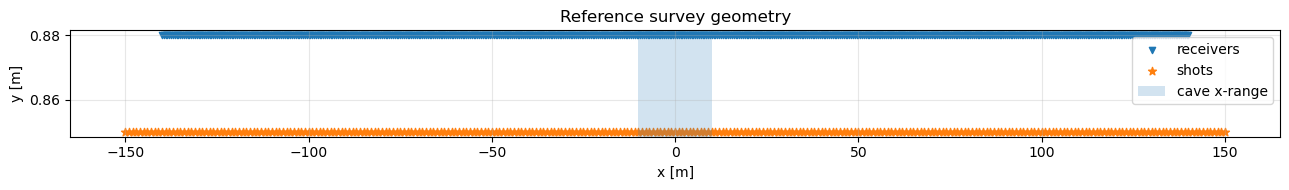

In [6]:
def plot_reference_geometry(receivers, shots, cfg):
    """
    Plot the reference survey geometry (receivers, shots, and cave footprint).

    Parameters
    ----------
    receivers : pandas.DataFrame
        DataFrame containing receiver positions with columns:
        ['x_m', 'y_m'].

    shots : pandas.DataFrame
        DataFrame containing shot positions with columns:
        ['x_m', 'y_m'].

    cfg : dict
        YAML configuration dictionary containing cave geometry.

    Notes
    -----
    - Receivers are plotted as triangles.
    - Shots are plotted as stars.
    - A small vertical offset is applied to improve visibility:
        receivers: y + 1.0
        shots:     y + 0.9
    - The cave is shown as a shaded region in x only.
    - This is a schematic visualization, not a true depth plot.
    """

    fig, ax = plt.subplots(figsize=(13, 2))

    # Plot receivers
    ax.scatter(
        receivers["x_m"],
        receivers["y_m"] + 1,
        marker="v",
        s=20,
        label="receivers"
    )

    # Plot shots
    ax.scatter(
        shots["x_m"],
        shots["y_m"] + 0.9,
        marker="*",
        s=35,
        label="shots"
    )

    # Plot cave horizontal extent
    cave = cfg["cave"]
    ax.axvspan(
        cave["x_min_m"],
        cave["x_max_m"],
        alpha=0.2,
        label="cave x-range"
    )

    # Labels and formatting
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title("Reference survey geometry")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig, ax


# Call the function
plot_reference_geometry(receivers, shots, cfg)

## 5. Build Travel-Time Acquisition Scheme (PyGIMLi)

This section converts the survey geometry (shots and receivers) into a **PyGIMLi travel-time acquisition scheme**.

---

### 🔹 What is a "scheme"?

In PyGIMLi, a *scheme* (`DataContainer`) defines:

- Sensor locations (shared pool of points)
- Source indices (`s`)
- Receiver indices (`g`)
- Valid source–receiver pairs

Each row in the scheme corresponds to a **single travel-time measurement**.

---

### 🔹 Key idea

We build all possible shot–receiver pairs:

```
for each shot:
    for each receiver:
        compute travel time
```
This produces:

- Dense coverage of raypaths
- Maximum sensitivity to subsurface structure
- A reference dataset for later decimation

---

### 🔹 Why use a shared sensor list?

PyGIMLi stores all positions in a **single sensor array**, and uses indices:

- `s` = source index
- `g` = receiver index

This avoids duplication when shots and receivers share locations.

---

### 🔹 Important implementation detail

Sensor coordinates are **rounded to 6 decimal places** before being stored.

This prevents:
- Floating-point duplicates
- Nearly identical coordinates being treated as separate sensors

---

### 🔹 Output

The function returns a `DataContainer` containing:

- Sensor coordinates
- Source–receiver pair indices
- Valid flags

You should expect:

- Number of sensors ≈ receivers + shots (minus overlaps)
- Number of pairs ≈ receivers × shots

---

### 🔹 Future step: Raypath visualization

This scheme will later be used to:

- Compute travel times
- Trace raypaths through the mesh
- Visualize how rays interact with the cave

This is critical for understanding:

- Which offsets are most sensitive
- How rays bend around the void
- Why aperture matters more than spacing


In [7]:
def make_explicit_tt_scheme(shots, receivers):
    """
    Create a PyGIMLi travel-time acquisition scheme from shot and receiver tables.

    All shot-receiver pairs are included except identical source/receiver sensor
    positions. With 301 shots and 3001 receivers, this creates about 903k pairs.
    """
    data = pg.DataContainer()
    data.registerSensorIndex("s")
    data.registerSensorIndex("g")

    sensor_lookup = {}

    def add_sensor(x, y):
        key = (round(float(x), 6), round(float(y), 6))
        if key not in sensor_lookup:
            sensor_lookup[key] = data.createSensor([float(x), float(y), 0.0])
        return int(sensor_lookup[key])

    shot_sensor_ids = [add_sensor(row["x_m"], row["y_m"]) for _, row in shots.iterrows()]
    receiver_sensor_ids = [add_sensor(row["x_m"], row["y_m"]) for _, row in receivers.iterrows()]

    S, G = [], []
    for sid in shot_sensor_ids:
        for gid in receiver_sensor_ids:
            if sid != gid:
                S.append(sid)
                G.append(gid)

    data.resize(len(S))
    data.set("s", S)
    data.set("g", G)
    data.set("valid", np.ones(len(S), dtype=int))

    return data


scheme = make_explicit_tt_scheme(shots, receivers)

print(f"Reference scheme: {scheme.sensorCount():,} unique sensors")
print(f"Travel-time pairs: {scheme.size():,}")


Reference scheme: 862 unique sensors
Travel-time pairs: 168,861


## 6. Build the PyGIMLi Mesh

This section converts the YAML-defined earth model, cave geometry, refinement zones, and acquisition points into a PyGIMLi mesh.

The mesh is the numerical grid used for travel-time forward modelling. It defines:

- Layer boundaries
- Cave/void geometry
- Cave refinement buffer
- Source and receiver node locations
- Cell markers used to assign velocities and material properties

---

### Layer geometry

The function `make_layer_geometry()` creates one polygon per earth-model layer.

Each layer is assigned a unique marker:

- Marker 1: first layer
- Marker 2: second layer
- etc.

These markers are later used to assign physical properties such as:

- P-wave velocity
- S-wave velocity
- Density
- Attenuation parameters

---

### Cave geometry

The function `make_cave_geometry()` creates the target cave or void.

Supported geometries:

- `rectangle`
- `circle`
- `ellipse`

For the current reference model, the cave is a water-filled rectangle centred beneath the survey line.

The cave receives its own marker so that it can be assigned water properties instead of limestone properties.

---

### Cave buffer refinement region

The function `make_cave_buffer_geometry()` creates a refinement halo around the cave.

This buffer is **not** assigned cave properties. It is still assigned ordinary layer properties based on depth.

Its purpose is purely numerical:

- Refine the mesh around the cave
- Improve representation of ray bending
- Reduce numerical artefacts near the velocity contrast
- Make travel-time perturbations more reliable

This is important because the strongest gradients and raypath distortions may occur just outside the cave boundary.

---

### Acquisition nodes

Source and receiver positions from the PyGIMLi acquisition scheme are explicitly added as mesh nodes.

This ensures that:

- Shots and receivers lie exactly on mesh vertices
- Travel-time calculations are tied to the intended survey geometry
- Raypath calculations are numerically stable

---

### With-cave and no-cave meshes

Two meshes are generated:

1. `mesh_no_cave`
   - Includes layers and cave refinement buffer
   - Does **not** include the cave anomaly
   - Represents the background model

2. `mesh_with_cave`
   - Includes layers, cave refinement buffer, and cave geometry
   - Represents the target model

The two meshes are used to compute paired travel-time datasets:

- Background travel times
- With-cave travel times
- Difference between the two gives the synthetic cave signal

---

### Marker diagnostics

At the end of the cell, the code prints marker summaries for both meshes.

This is an important quality-control step.

Expected behaviour:

- The no-cave mesh should contain layer markers and the buffer marker
- The with-cave mesh should contain layer markers, the buffer marker, and the cave marker

If the cave marker is missing from the with-cave mesh, then the cave was not inserted correctly.

In [8]:
def make_layer_geometry(cfg, pgcfg):
    """
    Create PyGIMLi polygon geometry for the layered earth model.

    Parameters
    ----------
    cfg : dict
        YAML configuration dictionary containing domain and earth_model entries.

    pgcfg : dict
        PyGIMLi configuration dictionary containing mesh settings.

    Returns
    -------
    pygimli.meshtools.PLC
        Piecewise linear complex representing the layered background geometry.

    Notes
    -----
    Each layer is represented as a closed polygon spanning the full horizontal
    model domain. Layer markers begin at 1 and increase sequentially.

    These markers are later used to assign material properties to mesh cells.
    """
    x0 = float(cfg["domain"]["x_min_m"])
    x1 = float(cfg["domain"]["x_max_m"])

    geom = None

    for marker, layer in enumerate(cfg["earth_model"]["layers"], start=1):
        top = depth_to_y(layer["z_min_m"])
        bottom = depth_to_y(layer["z_max_m"])

        poly = mt.createPolygon(
            [[x0, top], [x1, top], [x1, bottom], [x0, bottom]],
            isClosed=True,
            marker=marker,
            area=pgcfg["mesh_area_m2"],
        )

        geom = poly if geom is None else geom + poly

    return geom


def make_cave_buffer_geometry(cfg, pgcfg, marker):
    """
    Create a mesh-refinement buffer around the cave.

    Parameters
    ----------
    cfg : dict
        YAML configuration dictionary containing cave and domain definitions.

    pgcfg : dict
        PyGIMLi configuration dictionary containing cave-buffer settings.

    marker : int
        Marker assigned to the cave-buffer region.

    Returns
    -------
    pygimli.meshtools.PLC or None
        Polygon defining the cave refinement buffer, or None if buffer size is zero.

    Notes
    -----
    The cave buffer is not assigned cave material properties. It is used only to
    force a finer mesh near the cave, where ray bending and travel-time gradients
    are expected to be strongest.

    Material properties inside this buffer are still assigned from the normal
    layered earth model based on cell depth.
    """
    cave = cfg["cave"]
    buffer_m = float(pgcfg.get("cave_buffer_m", 0.0))

    if buffer_m <= 0:
        return None

    x0 = float(cave["x_min_m"]) - buffer_m
    x1 = float(cave["x_max_m"]) + buffer_m

    z0 = max(
        float(cfg["domain"]["z_min_m"]),
        float(cave["z_min_m"]) - buffer_m,
    )
    z1 = min(
        float(cfg["domain"]["z_max_m"]),
        float(cave["z_max_m"]) + buffer_m,
    )

    return mt.createPolygon(
        [
            [x0, depth_to_y(z0)],
            [x1, depth_to_y(z0)],
            [x1, depth_to_y(z1)],
            [x0, depth_to_y(z1)],
        ],
        isClosed=True,
        marker=marker,
        area=pgcfg["cave_buffer_mesh_area_m2"],
    )


def make_cave_geometry(cfg, pgcfg, marker):
    """
    Create PyGIMLi polygon geometry for the cave or void.

    Parameters
    ----------
    cfg : dict
        YAML configuration dictionary containing cave geometry.

    pgcfg : dict
        PyGIMLi configuration dictionary containing cave mesh settings.

    marker : int
        Marker assigned to the cave region.

    Returns
    -------
    pygimli.meshtools.PLC
        Polygon representing the cave geometry.

    Raises
    ------
    ValueError
        If the requested cave geometry is not supported.

    Notes
    -----
    Supported geometries are:

    - rectangle
    - circle
    - ellipse

    The current reference model uses a rectangular water-filled cave. The cave
    marker is later used to assign water properties, such as low P-wave velocity,
    zero S-wave velocity, and low density.
    """
    cave = cfg["cave"]
    geometry = cave.get("geometry", "rectangle").lower()

    if geometry == "rectangle":
        x0 = float(cave["x_min_m"])
        x1 = float(cave["x_max_m"])
        top = depth_to_y(cave["z_min_m"])
        bottom = depth_to_y(cave["z_max_m"])

        return mt.createPolygon(
            [[x0, top], [x1, top], [x1, bottom], [x0, bottom]],
            isClosed=True,
            marker=marker,
            area=pgcfg["cave_mesh_area_m2"],
        )

    if geometry in ("circle", "ellipse"):
        cx = float(
            cave.get(
                "center_x_m",
                0.5 * (cave["x_min_m"] + cave["x_max_m"]),
            )
        )
        cz = float(
            cave.get(
                "center_z_m",
                0.5 * (cave["z_min_m"] + cave["z_max_m"]),
            )
        )
        rx = float(
            cave.get(
                "radius_x_m",
                0.5 * (cave["x_max_m"] - cave["x_min_m"]),
            )
        )
        rz = float(
            cave.get(
                "radius_z_m",
                0.5 * (cave["z_max_m"] - cave["z_min_m"]),
            )
        )

        theta = np.linspace(
            0,
            2 * np.pi,
            int(cave.get("n_segments", 64)),
            endpoint=False,
        )

        pts = np.column_stack(
            [
                cx + rx * np.cos(theta),
                depth_to_y(cz) + rz * np.sin(theta),
            ]
        )

        return mt.createPolygon(
            pts.tolist(),
            isClosed=True,
            marker=marker,
            area=pgcfg["cave_mesh_area_m2"],
        )

    raise ValueError(f"Unsupported cave geometry: {geometry}")


def make_pygimli_geometry(cfg, pgcfg, scheme, with_cave=True):
    """
    Build complete PyGIMLi geometry for either the no-cave or with-cave model.

    Parameters
    ----------
    cfg : dict
        YAML configuration dictionary.

    pgcfg : dict
        PyGIMLi configuration dictionary.

    scheme : pygimli.DataContainer
        Travel-time acquisition scheme containing source and receiver locations.

    with_cave : bool, optional
        If True, include the cave geometry. If False, build the background model
        without the cave anomaly.

    Returns
    -------
    tuple
        geom : pygimli.meshtools.PLC
            Complete geometry object.
        cave_marker : int
            Marker used for cave cells.
        buffer_marker : int
            Marker used for cave-buffer cells.

    Notes
    -----
    The geometry always includes:

    - Layer polygons
    - Cave-buffer refinement polygon
    - Source and receiver nodes

    The cave polygon is included only if `with_cave=True`.
    """
    geom = make_layer_geometry(cfg, pgcfg)

    cave_marker = len(cfg["earth_model"]["layers"]) + 1
    buffer_marker = cave_marker + 1

    buffer_geom = make_cave_buffer_geometry(
        cfg,
        pgcfg,
        marker=buffer_marker,
    )

    if buffer_geom is not None:
        geom += buffer_geom

    if with_cave:
        geom += make_cave_geometry(
            cfg,
            pgcfg,
            marker=cave_marker,
        )

    # Force all acquisition points to exist as mesh nodes.
    for pos in scheme.sensors():
        geom.createNode([pos.x(), pos.y()])

    return geom, cave_marker, buffer_marker


def make_mesh_from_yaml(cfg, pgcfg, scheme, with_cave=True):
    """
    Generate a PyGIMLi mesh from YAML-defined geometry.

    Parameters
    ----------
    cfg : dict
        YAML configuration dictionary.

    pgcfg : dict
        PyGIMLi configuration dictionary.

    scheme : pygimli.DataContainer
        Travel-time acquisition scheme.

    with_cave : bool, optional
        If True, include cave geometry. If False, generate the no-cave model.

    Returns
    -------
    tuple
        geom : pygimli.meshtools.PLC
            Geometry used to create the mesh.
        mesh : pygimli.Mesh
            Generated finite-element mesh.
        cave_marker : int
            Marker for cave cells.
        buffer_marker : int
            Marker for cave-buffer cells.

    Notes
    -----
    The mesh resolution is controlled by:

    - `mesh_area_m2`
    - `cave_mesh_area_m2`
    - `cave_buffer_mesh_area_m2`
    - `mesh_quality`

    The with-cave and no-cave meshes should be checked using marker summaries.
    """
    geom, cave_marker, buffer_marker = make_pygimli_geometry(
        cfg,
        pgcfg,
        scheme,
        with_cave=with_cave,
    )

    mesh = mt.createMesh(
        geom,
        quality=pgcfg["mesh_quality"],
        area=pgcfg["mesh_area_m2"],
        smooth=[1, 10],
    )

    return geom, mesh, cave_marker, buffer_marker


# Build paired meshes: background and with-cave model
geom_no_cave, mesh_no_cave, cave_marker, buffer_marker = make_mesh_from_yaml(
    cfg,
    pgcfg,
    scheme,
    with_cave=False,
)

geom_with_cave, mesh_with_cave, cave_marker, buffer_marker = make_mesh_from_yaml(
    cfg,
    pgcfg,
    scheme,
    with_cave=True,
)

# Mesh summaries
print(mesh_no_cave)
print(mesh_with_cave)

print(f"Cave marker: {cave_marker}; Cave buffer marker: {buffer_marker}")

print(
    "No-cave markers:",
    np.unique(mesh_no_cave.cellMarkers(), return_counts=True),
)

print(
    "With-cave markers:",
    np.unique(mesh_with_cave.cellMarkers(), return_counts=True),
)

Mesh: Nodes: 53742 Cells: 104243 Boundaries: 157984
Mesh: Nodes: 55845 Cells: 108417 Boundaries: 164261
Cave marker: 4; Cave buffer marker: 5
No-cave markers: (array([0, 1, 2, 3, 5]), array([23086, 35262, 19594, 25603,   698]))
With-cave markers: (array([0, 1, 2, 3, 4, 5]), array([24993, 34996, 19466, 27219,   871,   872]))


<Axes: title={'center': 'Reference mesh with cave outline'}, xlabel='x [m]', ylabel='y [m]'>

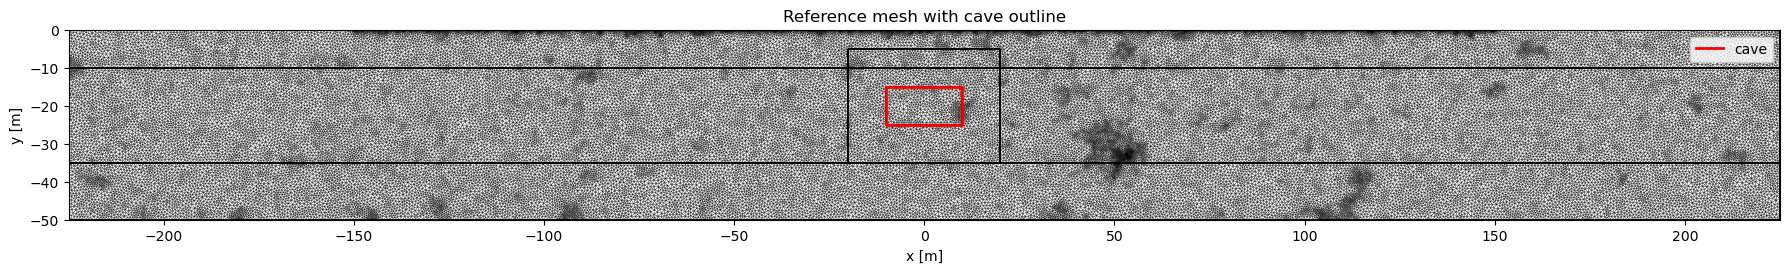

In [9]:
def plot_mesh_with_cave(mesh, cfg, title="PyGIMLi mesh"):
    """
    Plot the PyGIMLi mesh and cave outline.

    Parameters
    ----------
    mesh : pygimli.Mesh
        Mesh to plot.

    cfg : dict
        YAML configuration dictionary containing cave geometry.

    title : str
        Plot title.

    Returns
    -------
    matplotlib.axes.Axes
        Plot axis.
    """
    fig, ax = plt.subplots(figsize=(18, 6))

    pg.show(mesh, ax=ax, markers=False, showMesh=True)

    cave = cfg["cave"]
    cave_x = [
        cave["x_min_m"], cave["x_max_m"], cave["x_max_m"],
        cave["x_min_m"], cave["x_min_m"]
    ]
    cave_y = [
        -cave["z_min_m"], -cave["z_min_m"], -cave["z_max_m"],
        -cave["z_max_m"], -cave["z_min_m"]
    ]

    ax.plot(cave_x, cave_y, color="red", linewidth=2, label="cave")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()

    return ax


plot_mesh_with_cave(
    mesh_with_cave,
    cfg,
    title="Reference mesh with cave outline"
)

## 7. Assign Material Properties (Vp/Vs/density/Q) to Mesh Cells

This section converts the geometric mesh into numerical model arrays.

The previous section built the mesh geometry and assigned **cell markers** for:

- Background earth-model layers
- Cave refinement buffer
- Cave / void cells

This section assigns physical properties to every mesh cell.

---

### Model properties

For each mesh cell, the code builds arrays for:

- `vp` — P-wave velocity
- `vs` — S-wave velocity
- `rho` — density
- `qkappa` — bulk attenuation parameter
- `qmu` — shear attenuation parameter
- `markers` — mesh cell marker values

---

### Background material assignment

For normal earth-model cells, material properties are assigned based on the cell centre depth.

The helper function:

`material_properties_at_depth(cfg, depth)`

determines which layer the cell belongs to and returns the corresponding material properties.

If velocity or density gradients are enabled in the YAML file, they are applied at this step.

---

### Cave material assignment

If `with_cave=True`, cells marked with `cave_marker` are assigned cave/void properties from the YAML file.

For the current reference model, the cave is water-filled, so typical values are:

- Low P-wave velocity
- Zero S-wave velocity
- Low density
- Very high Q values

---

### Cave buffer region

The cave buffer is not assigned water properties.

It is only a mesh-refinement zone. Cells in the buffer are assigned ordinary layer properties based on depth.

This distinction is important:

- Cave cells represent the physical anomaly
- Buffer cells improve numerical accuracy around the anomaly

---

### No-cave versus with-cave models

Two material models are generated:

1. `model_no_cave`
   - Uses the no-cave mesh
   - All cells receive background layer properties
   - Represents the reference/background earth model

2. `model_with_cave`
   - Uses the with-cave mesh
   - Cave-marker cells receive water properties
   - Represents the target model

The travel-time difference between these two models is the synthetic cave signal.

---

### Quality-control output

The code prints the minimum and maximum P-wave velocities for each model.

Expected behaviour:

- No-cave model should show only background layer velocity range
- With-cave model should include the cave velocity
- If gradients are disabled, velocity values should match the YAML layer values
- If gradients are enabled, velocity ranges will reflect depth-dependent variation

In [10]:
def build_cell_models_from_yaml(mesh, cfg, cave_marker, with_cave=True):
    """
    Build cell-wise material property arrays from a PyGIMLi mesh and YAML config.

    For non-cave cells, properties are assigned by cell-centre depth using
    `material_properties_at_depth()`. This supports any number of layers and
    optional depth gradients. When gradients are disabled, top/bottom layer
    values are averaged.
    """
    markers = np.asarray(mesh.cellMarkers(), dtype=int)

    vp = np.zeros(mesh.cellCount(), dtype=float)
    vs = np.zeros(mesh.cellCount(), dtype=float)
    rho = np.zeros(mesh.cellCount(), dtype=float)
    qkappa = np.zeros(mesh.cellCount(), dtype=float)
    qmu = np.zeros(mesh.cellCount(), dtype=float)

    cave_mat = cave_material(cfg)

    for i, cell in enumerate(mesh.cells()):
        marker = int(markers[i])
        depth = y_to_depth(cell.center().y())

        if with_cave and marker == cave_marker:
            mat = cave_mat
            vp[i] = mat["vp"]
            vs[i] = mat["vs"]
            rho[i] = mat["rho"]
            qkappa[i] = mat["qkappa"]
            qmu[i] = mat["qmu"]
        else:
            mat = material_properties_at_depth(cfg, depth)
            vp[i] = mat["vp"]
            vs[i] = mat["vs"]
            rho[i] = mat["rho"]
            qkappa[i] = mat["qkappa"]
            qmu[i] = mat["qmu"]

    return {
        "vp": vp,
        "vs": vs,
        "rho": rho,
        "qkappa": qkappa,
        "qmu": qmu,
        "markers": markers,
    }


model_no_cave = build_cell_models_from_yaml(mesh_no_cave, cfg, cave_marker, with_cave=False)
model_with_cave = build_cell_models_from_yaml(mesh_with_cave, cfg, cave_marker, with_cave=True)

print("Vp no cave:", float(model_no_cave["vp"].min()), float(model_no_cave["vp"].max()))
print("Vp with cave:", float(model_with_cave["vp"].min()), float(model_with_cave["vp"].max()))
print("Vs no cave:", float(model_no_cave["vs"].min()), float(model_no_cave["vs"].max()))
print("Vs with cave:", float(model_with_cave["vs"].min()), float(model_with_cave["vs"].max()))

layer_summary = layer_property_summary(cfg)
layer_summary.to_csv(reference_dir / "effective_layer_properties.csv", index=False)
display(layer_summary)


Vp no cave: 1600.0 4700.0
Vp with cave: 1500.0 4700.0
Vs no cave: 800.0 2600.0
Vs with cave: 0.0 2600.0


,marker,name,z_min_m,z_max_m,z_mid_m,vp_effective_m_s,vs_effective_m_s,density_effective_kg_m3,qkappa,qmu
0,1,unsaturated_limestone,0.0,10.0,5.0,1600.0,800.0,2050.0,60.0,25.0
1,2,saturated_limestone_upper,10.0,35.0,22.5,3600.0,1800.0,2280.0,100.0,40.0
2,3,saturated_limestone_lower_or_basement,35.0,50.0,42.5,4700.0,2600.0,2450.0,150.0,60.0


### Visualize the Cell-Based Velocity Models

This cell plots the P-wave velocity models that were assigned to the PyGIMLi meshes.

Two models are shown:

1. **Reference Vp model: without cave**
   - Contains only the layered background model
   - Represents the expected travel times if no void is present

2. **Reference Vp model: with cave**
   - Contains the same layered background model
   - Adds the low-velocity water-filled cave anomaly

---

### Purpose

These plots are an important quality-control step before forward modelling.

They allow us to verify that:

- Layer velocities have been assigned correctly
- The cave anomaly appears in the expected location
- The cave has the expected low velocity
- The mesh refinement region does not accidentally receive cave properties
- Source and receiver locations are correctly positioned on the mesh

---

### Shared colour scale

Both plots use the same velocity colour scale:

- `vp_min` is computed from both models
- `vp_max` is computed from both models

This makes the two plots directly comparable.

---

### Sensor overlay

Shot and receiver positions are overlaid as white circles.

This helps confirm that:

- The acquisition geometry is centred over the cave
- Sensors lie on the model surface / shallow burial depth
- The survey aperture extends well beyond the target

---

### Interpretation

The no-cave model should show only the layered velocity structure.

The with-cave model should show a low-velocity zone at the expected cave location. If this anomaly is missing, misplaced, or assigned the wrong velocity, the geometry or marker assignment should be checked before running travel-time simulations.

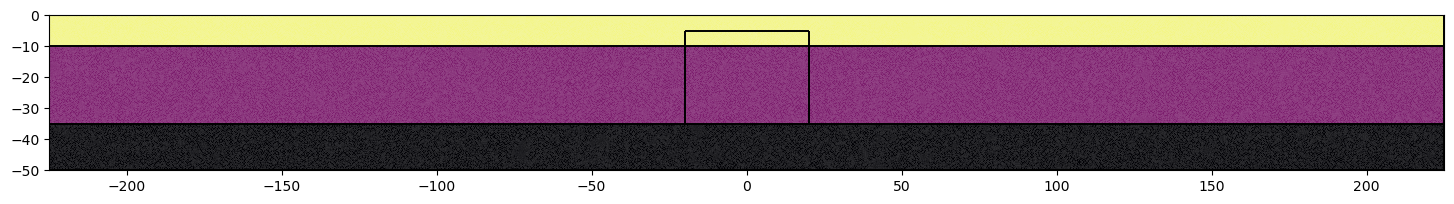

/Users/glennthompson/miniconda3/envs/pg/lib/python3.12/site-packages/pygimli/viewer/mpl/colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1800x600 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Axes: title={'center': 'Reference Vp model: with cave'}, xlabel='x [m]', ylabel='y [m]'>

<Figure size 640x480 with 0 Axes>

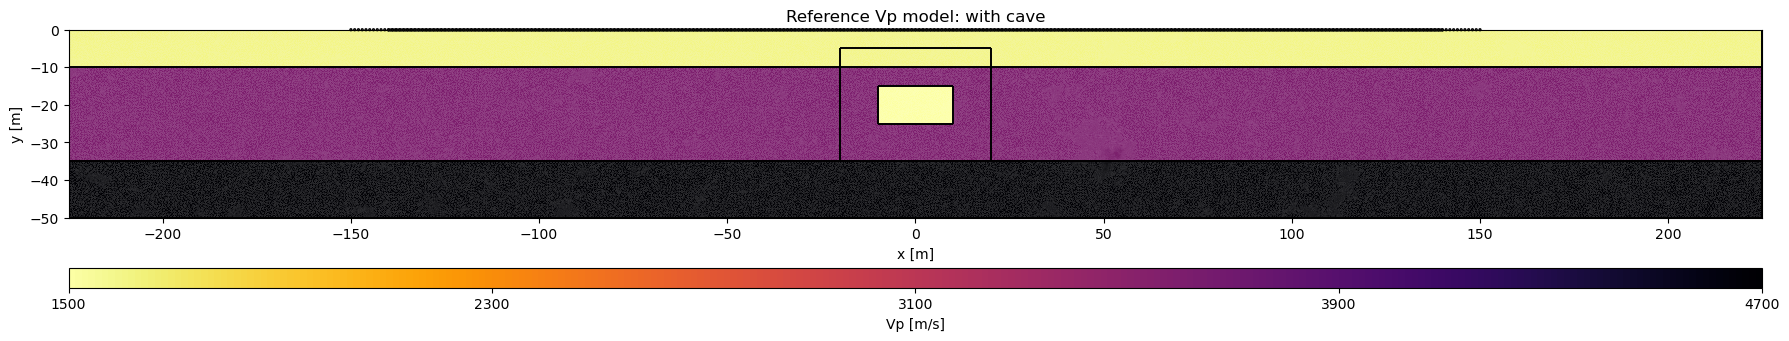

In [11]:
def draw_sensors(ax, scheme, diam=0.5):
    """Draw PyGIMLi sensor positions on an existing Matplotlib axis."""
    pg.viewer.mpl.drawSensors(
        ax,
        scheme.sensors(),
        diam=diam,
        facecolor="white",
        edgecolor="black",
    )


def velocity_color_limits(model_a, model_b, property_name="vp", pgcfg=None):
    """Return shared colour limits for paired no-cave/with-cave plots."""
    values = np.concatenate([np.asarray(model_a[property_name]), np.asarray(model_b[property_name])])
    vmin = float(np.nanmin(values))
    vmax = float(np.nanmax(values))

    if pgcfg is not None:
        plot_cfg = pgcfg.get("plotting", {})
        if property_name == "vp":
            vmin = float(plot_cfg.get("vp_cmin_m_s") or vmin)
            vmax = float(plot_cfg.get("vp_cmax_m_s") or vmax)

    return vmin, vmax


def nice_ticks(cmin, cmax, n=5):
    """Return simple evenly spaced colourbar ticks."""
    return np.linspace(float(cmin), float(cmax), int(n))


def plot_cell_model(
    mesh,
    values,
    scheme=None,
    title="",
    label="",
    cmin=None,
    cmax=None,
    cmap=None,
    ticks=None,
    outfile=None,
):
    """
    Plot a cell-based PyGIMLi model with optional sensor overlay.

    Use the same `cmin` and `cmax` for no-cave and with-cave models so the cave
    anomaly is visually comparable.
    """
    if cmap is None:
        cmap = pgcfg.get("plotting", {}).get("cmap", "inferno_r")

    fig, ax = plt.subplots(figsize=(18, 6))
    ax, cb = pg.show(
        mesh,
        values,
        ax=ax,
        colorBar=True,
        label=label,
        logScale=False,
        cMin=cmin,
        cMax=cmax,
        cMap=cmap,
    )

    if ticks is not None:
        cb.set_ticks(ticks)

    if scheme is not None:
        draw_sensors(ax, scheme)

    ax.set_title(title)
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    fig.tight_layout()

    if outfile is not None:
        outfile = Path(outfile)
        outfile.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(outfile, dpi=180)

    return ax


vp_cmin, vp_cmax = velocity_color_limits(model_no_cave, model_with_cave, "vp", pgcfg)
vp_ticks = nice_ticks(vp_cmin, vp_cmax, n=5)

plot_cell_model(
    mesh_no_cave,
    model_no_cave["vp"],
    scheme=scheme,
    title="Reference Vp model: without cave",
    label="Vp [m/s]",
    cmin=vp_cmin,
    cmax=vp_cmax,
    ticks=vp_ticks,
    outfile=figure_dir / "vp_model_without_cave.png",
)

plot_cell_model(
    mesh_with_cave,
    model_with_cave["vp"],
    scheme=scheme,
    title="Reference Vp model: with cave",
    label="Vp [m/s]",
    cmin=vp_cmin,
    cmax=vp_cmax,
    ticks=vp_ticks,
    outfile=figure_dir / "vp_model_with_cave.png",
)


## 8. Forward Model First-Arrival Travel Times

This section runs the PyGIMLi travel-time forward model for both the background and cave scenarios.

Two synthetic datasets are generated:

1. **No-cave model**
   - Travel times through the layered background only

2. **With-cave model**
   - Travel times through the same background model, but with the water-filled cave inserted

The difference between these two datasets is the synthetic seismic signal caused by the cave.

---

### Travel-time simulation

PyGIMLi travel-time modelling uses **slowness**, defined as:

`slowness = 1 / velocity`

In this notebook, the forward model uses the P-wave velocity model:

`slowness = 1 / Vp`

The function `simulate_first_arrivals()` calls:

`tt.simulate(...)`

to compute synthetic first-arrival travel times for every shot-receiver pair in the acquisition scheme.

---

### Noise model

Synthetic noise can be added to make the results more realistic.

Noise is controlled by:

- `noise_level_relative`
- `noise_abs_s`
- `seed`

The random seed ensures that results are reproducible.

---

### Error model

PyGIMLi inversions require every travel-time datum to have a strictly positive error value.

The helper function `set_positive_tt_errors()` ensures that:

- Invalid or non-finite travel times are removed
- Error values are positive
- A minimum absolute error floor is applied

This is important because some PyGIMLi workflows can fail if the `err` field contains zero, negative, or invalid values.

---

### Why both noise and error are used

Noise and error are related but not identical:

- **Noise** modifies the synthetic travel times
- **Error** tells the inversion how much confidence to assign to each datum

In this notebook, the synthetic noise is deliberately small so that we can isolate the effect of survey geometry on cave detectability.

---

### Output

The cell creates:

- `data_no_cave`
- `data_with_cave`

These are PyGIMLi `DataContainer` objects containing:

- Source indices
- Receiver indices
- Travel times
- Error estimates
- Valid-data flags

The printed error ranges provide a quick quality-control check before residual analysis or inversion.

In [12]:
def set_positive_tt_errors(data, relative_error=0.03, absolute_error_s=0.001):
    """
    Ensure that a PyGIMLi travel-time DataContainer has valid, positive errors.

    Parameters
    ----------
    data : pygimli.DataContainer
        Travel-time data container containing at least a `t` field for travel time.

    relative_error : float, optional
        Fractional error assigned relative to travel time. For example, 0.03
        corresponds to 3 percent.

    absolute_error_s : float, optional
        Minimum absolute error in seconds. This acts as an error floor.

    Returns
    -------
    pygimli.DataContainer
        The input data container, modified in place, with:
            - invalid travel times removed
            - positive `err` values assigned
            - valid flags updated

    Notes
    -----
    PyGIMLi travel-time inversion requires all error values to be strictly
    positive. This helper prevents failures caused by zero, negative, or
    non-finite errors.

    The error model used here is:

        err = max(relative_error * abs(t), absolute_error_s)

    where `t` is travel time.
    """
    t = np.asarray(data["t"], dtype=float)

    # Keep only finite, positive travel times.
    valid = np.isfinite(t) & (t > 0.0)

    # Compute positive error model.
    err = np.maximum(relative_error * np.abs(t), absolute_error_s)

    # Guard against non-finite or non-positive errors.
    err[~np.isfinite(err)] = absolute_error_s
    err[err <= 0.0] = absolute_error_s

    # Store error and validity flags, then remove invalid data.
    data.set("err", err)
    data.set("valid", valid.astype(int))
    data.removeInvalid()

    # Recompute errors after removing invalid data so array lengths match.
    t = np.asarray(data["t"], dtype=float)
    err = np.maximum(relative_error * np.abs(t), absolute_error_s)
    err[~np.isfinite(err)] = absolute_error_s
    err[err <= 0.0] = absolute_error_s

    data.set("err", err)

    return data


def copy_tt_data_with_positive_errors(data, relative_error=0.03, absolute_error_s=0.001):
    """
    Create a clean copy of a travel-time DataContainer with positive errors.

    Parameters
    ----------
    data : pygimli.DataContainer
        Original PyGIMLi travel-time data container.

    relative_error : float, optional
        Fractional error assigned relative to travel time.

    absolute_error_s : float, optional
        Minimum absolute error in seconds.

    Returns
    -------
    pygimli.DataContainer
        Copy of the input data container with valid, positive error values.

    Notes
    -----
    This is useful before inversion because it avoids modifying the original
    synthetic dataset and protects against PyGIMLi version-specific behaviour
    where invalid error values may persist.
    """
    clean = pg.DataContainer(data)

    return set_positive_tt_errors(
        clean,
        relative_error=relative_error,
        absolute_error_s=absolute_error_s,
    )


def simulate_first_arrivals(mesh, vp, scheme, pgcfg, add_noise=True):
    """
    Simulate first-arrival travel times using PyGIMLi.

    Parameters
    ----------
    mesh : pygimli.Mesh
        Mesh through which travel times are computed.

    vp : array-like
        Cell-wise P-wave velocity model in m/s.

    scheme : pygimli.DataContainer
        Travel-time acquisition scheme containing source and receiver indices.

    pgcfg : dict
        PyGIMLi configuration dictionary containing noise, error, and seed values.

    add_noise : bool, optional
        If True, add synthetic noise using `noise_level_relative` and
        `noise_abs_s`.

    Returns
    -------
    pygimli.DataContainer
        Simulated travel-time data with positive error values.

    Notes
    -----
    PyGIMLi travel-time simulation uses slowness, so the velocity model is
    converted using:

        slowness = 1 / Vp

    The returned data container is passed through `set_positive_tt_errors()` so
    that it is ready for residual analysis or inversion.
    
    Simulate first arrivals and return both data and manager.

    Returning mgr lets us draw raypaths from the computed forward operator.

    """

    mgr = tt.TravelTimeManager()

    data = mgr.simulate(
        mesh=mesh,
        slowness=1.0 / vp,
        scheme=scheme,
        noiseLevel=pgcfg["noise_level_relative"] if add_noise else 0.0,
        noiseAbs=pgcfg["noise_abs_s"] if add_noise else 0.0,
        seed=pgcfg["seed"],
        verbose=False,
    )

    data = set_positive_tt_errors(
        data,
        relative_error=pgcfg["error_relative"],
        absolute_error_s=pgcfg["error_abs_s"],
    )
    return data, mgr


# Create output directory for reference-model results
reference_dir = OUTPUT_DIR / "reference_model"
reference_dir.mkdir(parents=True, exist_ok=True)


# Forward model: background/no-cave case
data_no_cave, mgr_no_cave = simulate_first_arrivals(
    mesh_no_cave,
    model_no_cave["vp"],
    scheme,
    pgcfg,
    add_noise=True,
)


data_with_cave, mgr_with_cave = simulate_first_arrivals(
    mesh_with_cave,
    model_with_cave["vp"],
    scheme,
    pgcfg,
    add_noise=True,
)


# Quality-control output
print("No-cave data:", data_no_cave)
print("With-cave data:", data_with_cave)

print(
    "Error range, no cave:",
    float(np.min(data_no_cave["err"])),
    float(np.max(data_no_cave["err"])),
)

print(
    "Error range, with cave:",
    float(np.min(data_with_cave["err"])),
    float(np.max(data_with_cave["err"])),
)

15/05/26 - 15:10:47 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
15/05/26 - 15:12:24 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.


No-cave data: Data: Sensors: 862 data: 168770, nonzero entries: ['err', 'g', 's', 't', 'valid']
With-cave data: Data: Sensors: 862 data: 168770, nonzero entries: ['err', 'g', 's', 't', 'valid']
Error range, no cave: 0.0001 0.0001
Error range, with cave: 0.0001 0.0001


## 9. Convert Travel-Time Data to Analysis Tables

This section converts the PyGIMLi travel-time data into a **tabular format** (Pandas DataFrame) for analysis.

This is a critical step because:

- PyGIMLi stores data in a compact container format
- We want to analyze results using familiar tools (Pandas, plotting, statistics)

---

### 🔹 What is extracted?

For each shot–receiver pair, we compute:

- Source coordinates (`source_x_m`, `source_y_m`)
- Receiver coordinates (`receiver_x_m`, `receiver_y_m`)
- Offset (distance between source and receiver)
- Midpoint location
- Travel time (`t_s`)
- Error estimate (`err_s`, if available)

---

### 🔹 Why compute offset and midpoint?

These are key variables for interpretation:

- **Offset**
  - Controls ray depth penetration
  - Strongly influences sensitivity to the cave

- **Midpoint**
  - Approximate horizontal location of sensitivity
  - Used to localize anomalies (e.g., above the cave)

---

### 🔹 Build comparison dataset

Two datasets are merged:

- `df0`: no-cave travel times
- `df1`: with-cave travel times

They are joined on:

- source index (`s`)
- receiver index (`g`)

This produces a **paired dataset** where each row corresponds to the same raypath in both models.

---

### 🔹 Derived quantities

The following metrics are computed:

- `dt_s`  
  Difference in travel time:

  dt = t_with_cave - t_no_cave

- `dt_ms`  
Same difference in milliseconds

- `abs_dt_ms`  
Absolute magnitude of travel-time perturbation

- `percent_change`  
Relative change in travel time

These values quantify the **detectability of the cave**.

---

### 🔹 Output files

The following CSV files are written:

- Full travel-time comparison dataset  
- Receiver locations  
- Shot locations  

These files allow:

- Reproducibility
- External analysis (e.g., Excel, MATLAB)
- Sharing results without rerunning the model

---

### 🔹 Interpretation

This dataset is the foundation for all subsequent analysis:

- Offset-dependent sensitivity
- Midpoint localization of anomalies
- Survey design optimization
- Decimation experiments

In particular:

> The `dt_ms` values represent the synthetic seismic signal caused by the cave.


In [13]:
def scheme_dataframe(data):
    """
    Convert a PyGIMLi travel-time DataContainer into a Pandas DataFrame.

    Parameters
    ----------
    data : pygimli.DataContainer
        Travel-time data containing:
            - 's' (source indices)
            - 'g' (receiver indices)
            - 't' (travel times)

    Returns
    -------
    pandas.DataFrame
        DataFrame containing one row per shot–receiver pair, with columns:
            - s, g : source and receiver indices
            - source_x_m, source_y_m : source coordinates
            - receiver_x_m, receiver_y_m : receiver coordinates
            - offset_m : source–receiver distance
            - midpoint_x_m : horizontal midpoint between source and receiver
            - t_s : travel time (seconds)
            - err_s : travel-time error (if available)

    Notes
    -----
    Offset and midpoint are key derived quantities:

    - Offset controls ray depth penetration
    - Midpoint approximates horizontal sensitivity location

    These are used extensively in later analysis of cave detectability.
    """
    s = np.asarray(data["s"], dtype=int)
    g = np.asarray(data["g"], dtype=int)
    t = np.asarray(data["t"], dtype=float)

    sensors = data.sensors()

    # Extract source and receiver coordinates
    sx = np.array([sensors[i].x() for i in s], dtype=float)
    sy = np.array([sensors[i].y() for i in s], dtype=float)
    gx = np.array([sensors[i].x() for i in g], dtype=float)
    gy = np.array([sensors[i].y() for i in g], dtype=float)

    # Build DataFrame
    df = pd.DataFrame({
        "s": s,
        "g": g,
        "source_x_m": sx,
        "source_y_m": sy,
        "receiver_x_m": gx,
        "receiver_y_m": gy,
        "offset_m": np.sqrt((gx - sx)**2 + (gy - sy)**2),
        "midpoint_x_m": 0.5 * (sx + gx),
        "t_s": t,
    })

    # Add error column if available
    try:
        if "err" in data.tokenList():
            df["err_s"] = np.asarray(data["err"], dtype=float)
    except Exception:
        pass

    return df


# Convert PyGIMLi data to DataFrames
df0 = scheme_dataframe(data_no_cave).rename(columns={"t_s": "t_no_cave_s"})
df1 = scheme_dataframe(data_with_cave).rename(columns={"t_s": "t_with_cave_s"})


# Merge datasets to compare identical raypaths
df_reference = df0[
    ["s", "g", "source_x_m", "source_y_m",
     "receiver_x_m", "receiver_y_m",
     "offset_m", "midpoint_x_m", "t_no_cave_s"]
].merge(
    df1[["s", "g", "t_with_cave_s"]],
    on=["s", "g"],
    how="inner",
)


# Compute travel-time perturbations
df_reference["dt_s"] = (
    df_reference["t_with_cave_s"] - df_reference["t_no_cave_s"]
)

df_reference["dt_ms"] = 1000.0 * df_reference["dt_s"]
df_reference["abs_dt_ms"] = np.abs(df_reference["dt_ms"])

df_reference["percent_change"] = (
    100.0 * df_reference["dt_s"] / df_reference["t_no_cave_s"]
)


# Rounded coordinates for grouping / binning
df_reference["source_x_round_m"] = df_reference["source_x_m"].round(6)
df_reference["receiver_x_round_m"] = df_reference["receiver_x_m"].round(6)


# Save outputs
reference_csv = reference_dir / "reference_full_with_cave_minus_without_cave_traveltimes.csv"

df_reference.to_csv(reference_csv, index=False)
receivers.to_csv(reference_dir / "reference_receivers.csv", index=False)
shots.to_csv(reference_dir / "reference_shots.csv", index=False)


# Diagnostics
print(f"Wrote {reference_csv}")
print(df_reference["dt_ms"].describe())

display(df_reference.head())

Wrote /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/pygimli3/reference_model/reference_full_with_cave_minus_without_cave_traveltimes.csv
count    1.687700e+05
mean     1.772046e-03
std      3.744763e-02
min     -5.829277e-02
25%     -4.693623e-03
50%     -1.810216e-07
75%      1.251906e-03
max      7.728749e-01
Name: dt_ms, dtype: float64


,s,g,source_x_m,source_y_m,receiver_x_m,receiver_y_m,offset_m,midpoint_x_m,t_no_cave_s,t_with_cave_s,dt_s,dt_ms,abs_dt_ms,percent_change,source_x_round_m,receiver_x_round_m
0,0,301,-150.0,-0.05,-140.0,-0.12,10.000245,-145.00,0.006260,0.006260,-1.318078e-12,-1.318078e-09,1.318078e-09,-2.105520e-08,-150.0,-140.0
1,0,302,-150.0,-0.05,-139.5,-0.12,10.500233,-144.75,0.006610,0.006610,-2.085337e-11,-2.085337e-08,2.085337e-08,-3.154662e-07,-150.0,-139.5
2,0,303,-150.0,-0.05,-139.0,-0.12,11.000223,-144.50,0.006978,0.006978,-5.354981e-12,-5.354981e-09,5.354981e-09,-7.674484e-08,-150.0,-139.0
3,0,304,-150.0,-0.05,-138.5,-0.12,11.500213,-144.25,0.007283,0.007283,-7.505738e-11,-7.505738e-08,7.505738e-08,-1.030643e-06,-150.0,-138.5
4,0,305,-150.0,-0.05,-138.0,-0.12,12.000204,-144.00,0.007504,0.007504,-3.602395e-10,-3.602395e-07,3.602395e-07,-4.800659e-06,-150.0,-138.0


## 10. Save reusable forward-model products

The next cell writes the forward-model results to `OUTPUT_DIR/forward_cache/`. The companion analysis notebook reads these files and performs all decimation, subsetting, detectability diagnostics, and optional inversions without rerunning the expensive forward simulations.

In [14]:
# -----------------------------------------------------------------------------
# Cache forward-model products for downstream notebooks
# -----------------------------------------------------------------------------
# The forward simulations above are the expensive step. Save the reusable products
# in simple table formats so the subsetting / inversion notebook can work without
# rebuilding the mesh or rerunning ray tracing.

forward_cache_dir = OUTPUT_DIR / "forward_cache"
forward_cache_dir.mkdir(parents=True, exist_ok=True)

# CSV is the most portable. Parquet is faster/smaller if pyarrow/fastparquet is available.
forward_csv = forward_cache_dir / "reference_forward_traveltimes.csv"
df_reference.to_csv(forward_csv, index=False)

receivers_csv = forward_cache_dir / "reference_receivers.csv"
shots_csv = forward_cache_dir / "reference_shots.csv"
receivers.to_csv(receivers_csv, index=False)
shots.to_csv(shots_csv, index=False)

try:
    forward_parquet = forward_cache_dir / "reference_forward_traveltimes.parquet"
    df_reference.to_parquet(forward_parquet, index=False)
    parquet_status = str(forward_parquet)
except Exception as exc:
    parquet_status = f"not written ({type(exc).__name__}: {exc})"

manifest = {
    "config_file": str(CONFIG_FILE),
    "output_dir": str(OUTPUT_DIR),
    "forward_csv": str(forward_csv),
    "forward_parquet": parquet_status,
    "receivers_csv": str(receivers_csv),
    "shots_csv": str(shots_csv),
    "n_receivers": int(len(receivers)),
    "n_shots": int(len(shots)),
    "n_traveltimes": int(len(df_reference)),
    "gradient_enabled": bool(cfg["earth_model"].get("gradient", {}).get("enabled", False)),
    "receiver_spacing_m": float(cfg["survey"]["cabled"]["spacing_m"]),
    "shot_spacing_m": float(cfg["survey"]["shots"]["regular_spacing_m"]),
}

manifest_file = forward_cache_dir / "reference_forward_manifest.json"
with manifest_file.open("w") as f:
    json.dump(manifest, f, indent=2)

print("Forward-model cache written:")
print(f"  {forward_csv}")
print(f"  {receivers_csv}")
print(f"  {shots_csv}")
print(f"  {manifest_file}")
print(f"  parquet: {parquet_status}")

Forward-model cache written:
  /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/pygimli3/forward_cache/reference_forward_traveltimes.csv
  /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/pygimli3/forward_cache/reference_receivers.csv
  /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/pygimli3/forward_cache/reference_shots.csv
  /Users/glennthompson/Library/CloudStorage/Box-Box/thompsong/2026KarstGeophysicsDEP/02_Modelling/Seismic/pygimli3/forward_cache/reference_forward_manifest.json
  parquet: not written (ImportError: Unable to find a usable engine; tried using: 'pyarrow', 'fastparquet'.
A suitable version of pyarrow or fastparquet is required for parquet support.
Trying to import the above resulted in these errors:
 - `Import pyarrow` failed. pyarrow is required for parquet support. Use pip or conda to install the pyarr